# 4-Hour-Ahead Water Quality Forecasting (LSTM + Attention)

Forecasts a composite **Water Quality Index (WQI)** 4 hours ahead for three
Hanoi lake/treatment sites (**Bay Mau**, **Cau Nga**, **Ho Tay**), using
5-minute sensor logs from 2024.

## 0. Setup

In [1]:
%pip install tensorflow
#import tensorflow as tf
#print(tf.__version__)

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.15.0


In [3]:
import warnings
warnings.filterwarnings("ignore")

import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import joblib

pd.set_option("display.width", 120)
np.random.seed(42)
keras.utils.set_random_seed(42)

## 1. Load & clean one site

Each `.xlsx` file is a 5-minute sensor log with columns for inflow/outflow,
temperature, pH, TSS, COD, BOD, TOC, NO3, NH4, PO4, total N and total P.

In these specific files `do`, `bod`, `toc`, `total_n`, `total_p` are 100%
empty at every site, and `no3`/`po4` are only populated at some sites, so we
rely on the five parameters with reliable coverage everywhere: **temperature,
pH, TSS, COD, NH4-N**, plus the outflow channel.

Cleaning steps:
- coerce every column to numeric (a small number of cells were auto-converted
  to stray datetimes by Excel and are treated as missing)
- null out physically implausible readings (e.g. pH = 0, negative flow)
- re-index onto a strict 5-minute grid so lag/rolling features correspond to
  real elapsed time, not row count
- linearly interpolate 


In [ ]:
SITE_FILES = {
    "BAY_MAU": "BAY MAU.xlsx",
    "CAU_NGA": "CAU NGA.xlsx",
    "HO_TAY": "HO TAY.xlsx",
}

RAW_COLS = ["flow_in", "flow_out1", "flow_out2", "flow_out3",
            "temp", "ph", "tss", "cod", "nh4", "no3", "po4"]


def clean_numeric(s: pd.Series) -> pd.Series:
    """Coerce a messy column (strings, stray datetimes from Excel
    autoconvert, ints, floats) to float; anything unparsable -> NaN."""
    s = s.apply(lambda x: np.nan if isinstance(x, (dt.datetime, dt.date)) else x)
    return pd.to_numeric(s, errors="coerce")


def load_and_clean(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"]).drop_duplicates(subset=["datetime"])

    for c in RAW_COLS:
        if c in df.columns:
            df[c] = clean_numeric(df[c])

#Sort by times
    df = df.sort_values("datetime").set_index("datetime")

 # Resample to a regular 5-minute interval
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq="5min")
    df = df.reindex(full_idx)
    df.index.name = "datetime"

    core = ["temp", "ph", "tss", "cod", "nh4", "flow_in", "flow_out1", "no3", "po4"]
    for c in core:
        if c in df.columns:
            df[c] = df[c].interpolate(method="linear")
    return df


SITE_KEY = "CAU_NGA"  # change to BAY_MAU / CAU_NGA / HO_TAY to explore a different site
df = load_and_clean(SITE_FILES[SITE_KEY])
print(f"{SITE_FILES[SITE_KEY]}: {len(df):,} rows, {df.index.min()} -> {df.index.max()}")
df[["temp", "ph", "tss", "cod", "nh4", "flow_out1"]].describe().round(2)


Cau Nga: 84,571 rows, 2024-03-13 08:25:00 -> 2024-12-31 23:55:00


,temp,ph,tss,cod,nh4,flow_out1
count,84571.00,84571.00,84571.00,84571.00,84571.00,84571.00
mean,28.06,7.50,9.53,14.64,0.80,282.94
std,2.86,0.24,4.71,8.16,0.52,294.55
min,18.99,6.75,0.00,0.00,0.00,0.00
25%,26.73,7.31,6.27,9.35,0.46,3.65
50%,28.63,7.44,8.51,12.14,0.61,149.52
75%,30.07,7.63,11.82,18.45,1.09,547.81
max,33.83,8.69,82.05,188.83,8.28,1187.23


## 2. Build the Water Quality Index (WQI) target

"Water quality" is combined into a single 0-100 composite score using a
simplified sub-index / weighted-sum approach: each raw parameter is mapped to
a 0-100 quality score via a piecewise-linear function anchored on the
pollution thresholds in Vietnam's surface-water regulation, then combined as a weighted
average:

| Parameter | Weight | Why |
|---|---|---|
| COD | 0.35 | organic pollution |
| NH4-N | 0.35 | ammonia / nutrient pollution |
| TSS | 0.15 | suspended solids |
| pH | 0.15 | best 6.5-8.5, degrading toward the edges |



In [ ]:
def compute_wqi(df):

    # COD score
    df["cod_score"] = np.interp(
        df["cod"],
        [0, 15, 30, 50, 100],
        [100, 90, 75, 50, 0]
    )

    # NH4 score
    df["nh4_score"] = np.interp(
        df["nh4"],
        [0, 0.3, 0.9, 5],
        [100, 90, 50, 0]
    )

    # TSS score
    df["tss_score"] = np.interp(
        df["tss"],
        [0, 20, 30, 50, 200],
        [100, 90, 75, 50, 0]
    )

    # pH score
    df["ph_score"] = 100

    mask = df["ph"] < 6.5
    df.loc[mask, "ph_score"] = np.interp(
        df.loc[mask, "ph"],
        [5.0, 6.5],
        [20, 100]
    )

    mask = df["ph"] > 8.5
    df.loc[mask, "ph_score"] = np.interp(
        df.loc[mask, "ph"],
        [8.5, 10.0],
        [100, 20]
    )

    # Final WQI
    df["wqi"] = (
        0.35 * df["cod_score"] +
        0.35 * df["nh4_score"] +
        0.15 * df["tss_score"] +
        0.15 * df["ph_score"]
    )

    return df


df = compute_wqi(df)
wqi = df["wqi"]
print(wqi.describe())

count    84571.000000
mean        83.425862
std          6.680545
min         45.243427
25%         77.965816
50%         83.688250
75%         88.458542
max         96.690583
Name: wqi, dtype: float64


## 3. Look at the series

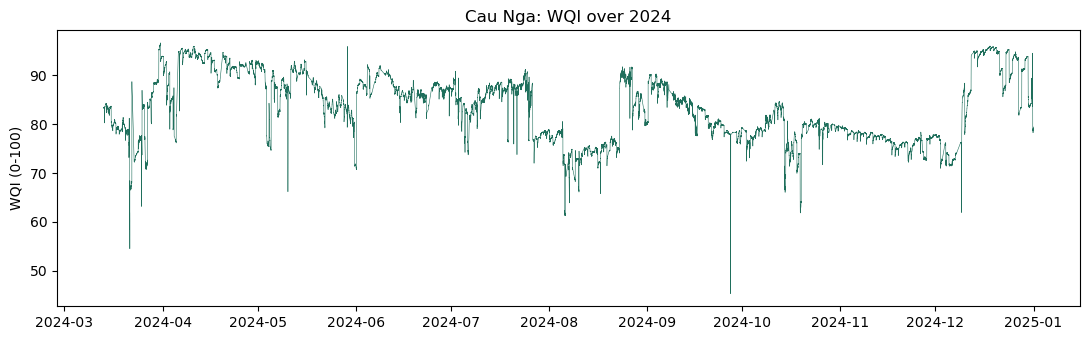

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(wqi.index, wqi.values, lw=0.4, color="#1f6f5c")
ax.set_title(f"{SITE_FILES[SITE_KEY]}: WQI over 2024")
ax.set_ylabel("WQI (0-100)")
plt.tight_layout()
plt.show()


## 4. Build windowed sequences

At 5-minute sampling, **4 hours = 48 steps**. Each training example uses the
past 4 hours (48 steps) of `[temp, ph, tss, cod, nh4, flow_out1, wqi]` to
predict WQI exactly 4 hours after the end of that window.

`flow_in` is dropped from the feature set because it's 100% missing at Cau
Nga; `flow_out1` is available at all three sites.


In [ ]:
TIME_WINDOW = 48   # lookback: 48 * 5min = 4 hours of history feeding the LSTM
HORIZON = 48        # forecast target: 48 * 5min = 4 hours ahead
FEATURE_COLS = ["temp", "ph", "tss", "cod", "nh4", "flow_out1"]
TARGET_COL = "wqi"


def build_matrix(df):

    cols = FEATURE_COLS + [TARGET_COL]

    mat = df[cols].copy()

    return mat.dropna()


def make_sequences(arr, target_idx,
                   time_window=TIME_WINDOW,
                   horizon=HORIZON):

    X, Y = [], []

    n = len(arr) - time_window - horizon + 1

    for i in range(n):

        # Only use the feature columns
        X.append(arr[i:i + time_window, :len(FEATURE_COLS)])

        # Target is WQI
        Y.append(arr[i + time_window + horizon - 1, target_idx])

    return np.array(X), np.array(Y)


mat = build_matrix(df)
target_idx = mat.columns.get_loc(TARGET_COL)
print(f"{len(mat):,} fully-complete timesteps available for sequencing "
      f"(out of {len(df):,} total)")
print(mat.head())
print(mat.shape)


84,571 fully-complete timesteps available for sequencing (out of 84,571 total)
                          temp    ph   tss    cod   nh4   flow_out1        wqi
datetime                                                                      
2024-03-13 08:25:00  22.760000  8.01  9.09  14.00  0.69  505.690002  83.451583
2024-03-13 08:30:00  22.719999  8.01  8.93  14.05  0.69  516.599976  83.451917
2024-03-13 08:35:00  22.690001  8.01  8.74  14.08  0.69  123.300003  83.459167
2024-03-13 08:40:00  22.680000  8.01  8.58  14.14  0.69   28.860001  83.457167
2024-03-13 08:45:00  22.680000  8.01  8.60  14.14  0.69    2.570000  83.455667
(84571, 7)


## 5. Chronological train/test split, then scale

The split happens **before** scaling and sequencing, so no information from
the test period leaks into the training-set statistics used to normalize
the data. The most recent 15% of the timeline is held out purely for testing.


In [42]:
# ============================================
# 5. Chronological train/test split, then scale
# ============================================

n = len(mat)
cut = int(n * 0.85)

train = mat.iloc[:cut]
test = mat.iloc[cut:]

print(f"Train: {len(train):,} rows")
print(f"Test : {len(test):,} rows")

# Scale using only the training data
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

# Create sequences
X_train, Y_train = make_sequences(train_scaled, target_idx)
X_test, Y_test = make_sequences(test_scaled, target_idx)



print("\nSequence shapes")
print(f"X_train: {X_train.shape}")
print(f"Y_train: {Y_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Y_test : {Y_test.shape}")


Train: 71,885 rows
Test : 12,686 rows

Sequence shapes
X_train: (71790, 48, 6)
Y_train: (71790,)
X_test : (12591, 48, 6)
Y_test : (12591,)


## 6. Model: LSTM with attention


In [43]:
def build_lstm_model(input_shape):

    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(100),
        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

model = build_lstm_model(
    input_shape=(TIME_WINDOW, len(FEATURE_COLS))
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 100)            │        42,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,901 (167.58 KB)

 Trainable params: 42,901 (167.58 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train

The last 10% of the training sequences (chronologically) are carved out as a
validation set for early stopping.


In [44]:
# 7. Train

es = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    Y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=256,
    callbacks=[es],
    verbose=2
)

Epoch 1/15
253/253 - 31s - 124ms/step - loss: 0.0177 - mae: 0.0722 - val_loss: 7.4958e-04 - val_mae: 0.0228
Epoch 2/15
253/253 - 43s - 170ms/step - loss: 0.0021 - mae: 0.0289 - val_loss: 5.1816e-04 - val_mae: 0.0187
Epoch 3/15
253/253 - 42s - 165ms/step - loss: 0.0020 - mae: 0.0273 - val_loss: 3.6890e-04 - val_mae: 0.0143
Epoch 4/15
253/253 - 41s - 161ms/step - loss: 0.0019 - mae: 0.0261 - val_loss: 3.3208e-04 - val_mae: 0.0128
Epoch 5/15
253/253 - 43s - 171ms/step - loss: 0.0018 - mae: 0.0254 - val_loss: 3.0205e-04 - val_mae: 0.0126
Epoch 6/15
253/253 - 41s - 161ms/step - loss: 0.0017 - mae: 0.0247 - val_loss: 2.8081e-04 - val_mae: 0.0120
Epoch 7/15
253/253 - 43s - 172ms/step - loss: 0.0017 - mae: 0.0240 - val_loss: 3.2850e-04 - val_mae: 0.0127
Epoch 8/15
253/253 - 44s - 172ms/step - loss: 0.0016 - mae: 0.0234 - val_loss: 4.4234e-04 - val_mae: 0.0155
Epoch 9/15
253/253 - 41s - 163ms/step - loss: 0.0016 - mae: 0.0230 - val_loss: 5.8727e-04 - val_mae: 0.0180
Epoch 10/15
253/253 - 80s - 

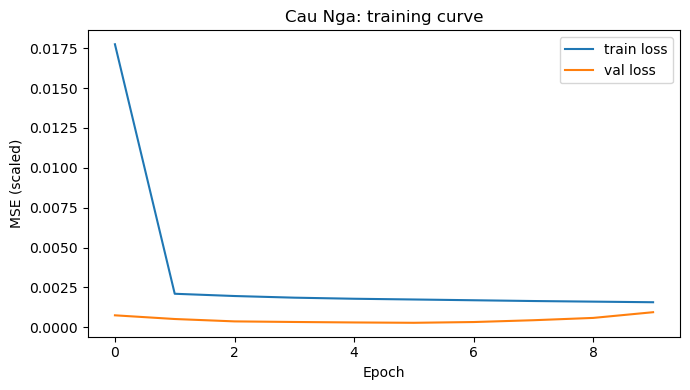

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history["loss"], label="train loss")
ax.plot(history.history["val_loss"], label="val loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled)")
ax.set_title(f"{SITE_FILES[SITE_KEY]}: training curve")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Evaluate on the held-out test set

In [46]:
# Predict WQI on the test set
pred = model.predict(X_test, verbose=0).ravel()

print(pred.shape)

(12591,)


In [47]:
target_idx = mat.columns.get_loc("wqi")

wqi_min = scaler.data_min_[target_idx]
wqi_max = scaler.data_max_[target_idx]

pred_real = pred * (wqi_max - wqi_min) + wqi_min
actual_real = Y_test * (wqi_max - wqi_min) + wqi_min

mae = mean_absolute_error(actual_real, pred_real)
rmse = np.sqrt(mean_squared_error(actual_real, pred_real))
r2 = r2_score(actual_real, pred_real)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MAE : 2.57
RMSE: 3.29
R²  : 0.859


## 10. Plots

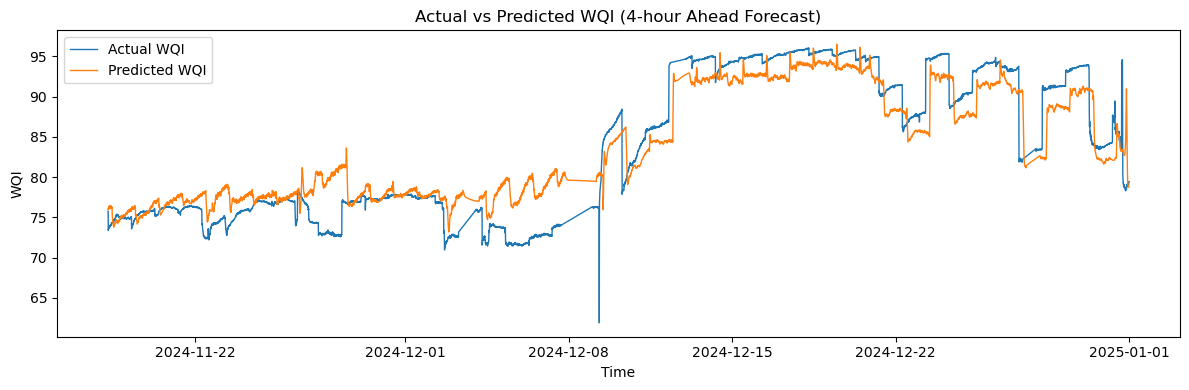

In [48]:
# Time index for the test predictions
test_index = test.index[
    TIME_WINDOW + HORIZON - 1 :
    TIME_WINDOW + HORIZON - 1 + len(actual_real)
]

plt.figure(figsize=(12, 4))

plt.plot(
    test_index,
    actual_real,
    label="Actual WQI",
    linewidth=1
)

plt.plot(
    test_index,
    pred_real,
    label="Predicted WQI",
    linewidth=1
)

plt.title("Actual vs Predicted WQI (4-hour Ahead Forecast)")
plt.xlabel("Time")
plt.ylabel("WQI")
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
target_idx = mat.columns.get_loc("wqi")

wqi_min = scaler.data_min_[target_idx]
wqi_max = scaler.data_max_[target_idx]

pred_real = pred * (wqi_max - wqi_min) + wqi_min
actual_real = Y_test * (wqi_max - wqi_min) + wqi_min

mae = mean_absolute_error(actual_real, pred_real)
rmse = np.sqrt(mean_squared_error(actual_real, pred_real))
r2 = r2_score(actual_real, pred_real)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MAE : 2.57
RMSE: 3.29
R²  : 0.859


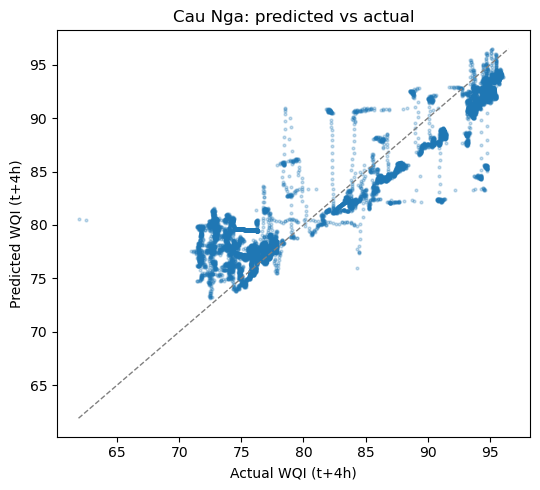

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(actual_real, pred_real, s=4, alpha=0.25)
lims = [min(actual_real.min(), pred_real.min()), max(actual_real.max(), pred_real.max())]
ax.plot(lims, lims, "--", color="gray", lw=1)
ax.set_xlabel("Actual WQI (t+4h)")
ax.set_ylabel("Predicted WQI (t+4h)")
ax.set_title(f"{SITE_FILES[SITE_KEY]}: predicted vs actual")
plt.tight_layout()
plt.show()




## 11. Save the model

In [21]:
model.save(f"lstm_{SITE_KEY}.keras")

joblib.dump(
    {
        "scaler": scaler,
        "feature_cols": FEATURE_COLS,
        "time_window": TIME_WINDOW,
        "horizon": HORIZON,
        "target_idx": target_idx,
    },
    f"lstm_meta_{SITE_KEY}.pkl",
)

print(f"Saved model and metadata for {SITE_KEY}")

Saved model and metadata for CAU_NGA


## 12. Run the same pipeline on the remaining sites

The cell above already trained and evaluated one site in full. Here we wrap
the same steps into a function and run it on the other two sites, then
combine everything into one comparison table (this retrains from scratch for
those two sites only — a couple of minutes on CPU).


In [ ]:
def run_site(site_key, epochs=10, verbose=0):

    # Load and prepare data
    df = load_and_clean(SITE_FILES[site_key])
    df = compute_wqi(df)                     # compute WQI column
    mat = build_matrix(df)

    target_idx = mat.columns.get_loc(TARGET_COL)

    # -------------------------
    # Train / Test split
    # -------------------------
    n = len(mat)
    cut = int(n * 0.85)

    train = mat.iloc[:cut]
    test = mat.iloc[cut:]

    # -------------------------
    # Scale
    # -------------------------
    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    # -------------------------
    # Create sequences
    # -------------------------
    X_train, Y_train = make_sequences(train_scaled, target_idx)
    X_test, Y_test = make_sequences(test_scaled, target_idx)

    # -------------------------
    # Build & train model
    # -------------------------
    model = build_lstm_model((TIME_WINDOW, len(FEATURE_COLS)))

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        Y_train,
        validation_split=0.1,
        epochs=15,
        batch_size=256,
        callbacks=[es],
        verbose=verbose,
    )

    # -------------------------
    # Predict
    # -------------------------
    pred_scaled = model.predict(
        X_test,
        verbose=0
    ).ravel()

    # Convert back to original WQI scale
    wqi_min = scaler.data_min_[target_idx]
    wqi_max = scaler.data_max_[target_idx]

    pred = pred_scaled * (wqi_max - wqi_min) + wqi_min
    actual = Y_test * (wqi_max - wqi_min) + wqi_min


    # ============================================
    # Save model
    # ============================================

    model.save(f"lstm_{site_key}.keras")

    joblib.dump(
        {
            "scaler": scaler,
            "feature_cols": FEATURE_COLS,
            "time_window": TIME_WINDOW,
            "horizon": HORIZON,
            "target_idx": target_idx,
        },
        f"lstm_meta_{site_key}.pkl",
    )

    print(f"Saved model and metadata for {SITE_FILES[site_key]}")

    # -------------------------
    # Return metrics
    # -------------------------
    return {
        "site": SITE_FILES[site_key],
        "n_test": len(actual),
        "model_mae": mean_absolute_error(actual, pred),
        "model_rmse": np.sqrt(mean_squared_error(actual, pred)),
        "model_r2": r2_score(actual, pred),

        "actual": actual,
        "pred": pred,
        "time": test.index[
            TIME_WINDOW + HORIZON - 1 :
            TIME_WINDOW + HORIZON - 1 + len(actual)
            ],

        # Next 4-hour prediction
        "next_4h_wqi": pred[-1]
}





In [52]:
# Run on all sites
results_by_site = {}

for key in SITE_FILES:
    results_by_site[key] = run_site(key)

summary = (
    pd.DataFrame([
        {
            "site": r["site"],
            "n_test": r["n_test"],
            "model_mae": r["model_mae"],
            "model_rmse": r["model_rmse"],
            "model_r2": r["model_r2"]
        }
        for r in results_by_site.values()
    ])
    .set_index("site")
    .round(3)
)

summary

Saved model and metadata for Bay Mau
Saved model and metadata for Cau Nga
Saved model and metadata for Ho Tay


,n_test,model_mae,model_rmse,model_r2
site,,,,
Bay Mau,15715,0.928,1.694,0.421
Cau Nga,12591,2.550,3.181,0.868
Ho Tay,12591,1.058,1.425,-0.395


In [53]:
print("Predicted WQI 4 hours ahead\n")

for result in results_by_site.values():
    print(f"{result['site']}: {result['next_4h_wqi']:.2f}")

Predicted WQI 4 hours ahead

Bay Mau: 76.91
Cau Nga: 78.52
Ho Tay: 76.09


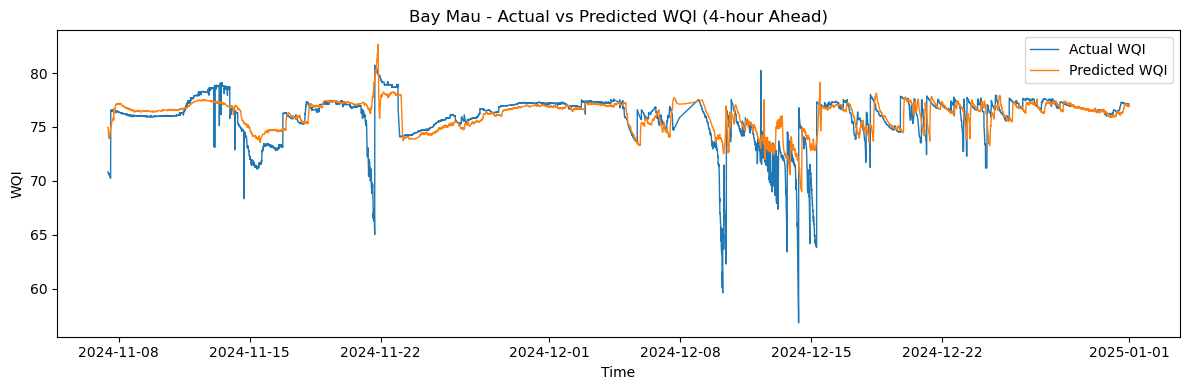

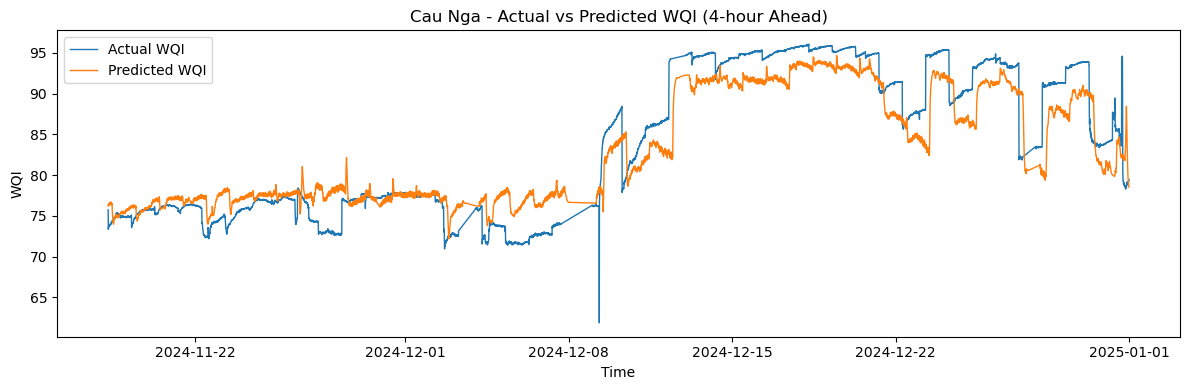

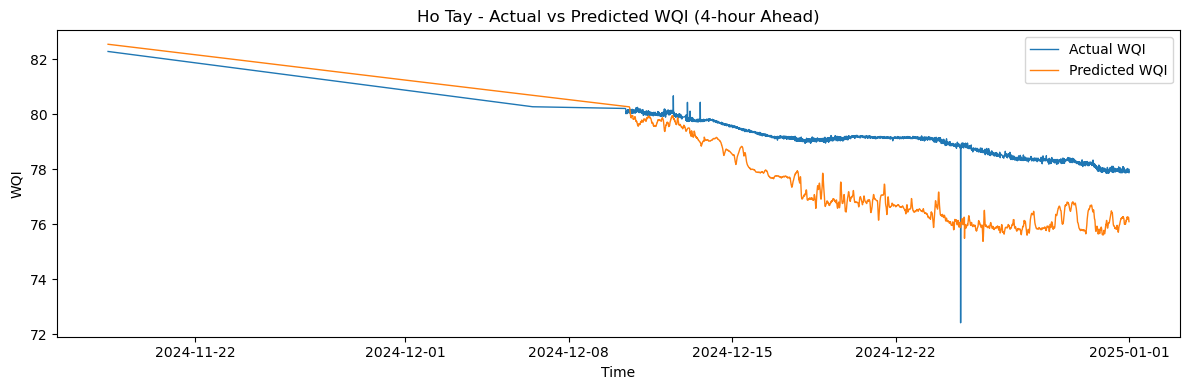

In [54]:
for result in results_by_site.values():

    plt.figure(figsize=(12,4))

    plt.plot(
        result["time"],
        result["actual"],
        label="Actual WQI",
        linewidth=1
    )

    plt.plot(
        result["time"],
        result["pred"],
        label="Predicted WQI",
        linewidth=1
    )

    plt.title(f"{result['site']} - Actual vs Predicted WQI (4-hour Ahead)")
    plt.xlabel("Time")
    plt.ylabel("WQI")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [38]:
print(df.isna().sum())

flow_in      84571
flow_out1        0
flow_out2    84571
flow_out3    84571
temp             0
ph               0
tss              0
do           84571
cod              0
bod          84571
toc          84571
no3              0
nh4              0
po4          84571
total_n      84571
total_p      84571
dtype: int64
